In [4]:
# TEST: tek bir çift hesapla, çalışıyor mu?
import numpy as np
import sklearn
from sklearn.feature_selection import mutual_info_regression
from pesummary.io import read

print("Import tamam", flush=True)

file_name = "/Users/omerfaruk/Desktop/PHYS400-Code/PHYS400/Data/IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5"
f = read(file_name, disable_conversion=True)
label = f.labels[0]
samples = f.samples_dict[label]

PARAMS = [
    "mass_1_source", "mass_2_source",
    "a_1", "a_2", "tilt_1", "tilt_2",
    "phi_12", "phi_jl",
    "luminosity_distance", "theta_jn",
    "psi", "azimuth", "zenith",
    "geocent_time", "phase"
]
SHORT = ["m1","m2","a1","a2","t1","t2","p12","pJL","dL","iota","psi","az","zen","tc","pc"]

data = np.array([samples[p] for p in PARAMS]).T
print(f"Data shape: {data.shape}", flush=True)

# Sadece 2000 sample ile tek çift test et
np.random.seed(42)
idx = np.random.choice(len(data), 2000, replace=False)
x = data[idx, 0].reshape(-1, 1)   # mass_1
y = data[idx, 1]                   # mass_2

print("Hesaplıyor...", flush=True)
mi = mutual_info_regression(x, y, n_neighbors=5, random_state=42)[0]
print(f"m1 — m2: {mi * 1.4427:.4f} bits", flush=True)
print("Test başarılı!", flush=True)

Import tamam


2026-05-28  01:20:03 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


Data shape: (147634, 15)
Hesaplıyor...
m1 — m2: 0.5901 bits
Test başarılı!


2026-05-28  01:20:51 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


Yüklendi: 147634 sample, 15 parametre
ADIM 1: Pairwise MI matrisi hesaplanıyor...
MI hesabı için 10000 sample kullanılıyor (147634'den alt küme)

Toplam 105 çift hesaplanacak...

Çift                    MI (bits)
-----------------------------------
  m1    — m2   :   0.5597 bits  (1/105)
  m1    — a1   :   0.0286 bits  (2/105)
  m1    — a2   :   0.0191 bits  (3/105)
  m1    — θ1   :   0.0650 bits  (4/105)
  m1    — θ2   :   0.0219 bits  (5/105)
  m1    — φ12  :   0.0259 bits  (6/105)
  m1    — φJL  :   0.0337 bits  (7/105)
  m1    — dL   :   0.0284 bits  (8/105)
  m1    — ι    :   0.0391 bits  (9/105)
  m1    — ψ    :   0.0210 bits  (10/105)
  m1    — az   :   0.0519 bits  (11/105)
  m1    — zen  :   0.0270 bits  (12/105)
  m1    — tc   :   0.0094 bits  (13/105)
  m1    — φc   :   0.0231 bits  (14/105)
  m2    — a1   :   0.0477 bits  (15/105)
  m2    — a2   :   0.0281 bits  (16/105)
  m2    — θ1   :   0.0396 bits  (17/105)
  m2    — θ2   :   0.0513 bits  (18/105)
  m2    — φ12  :   0.0

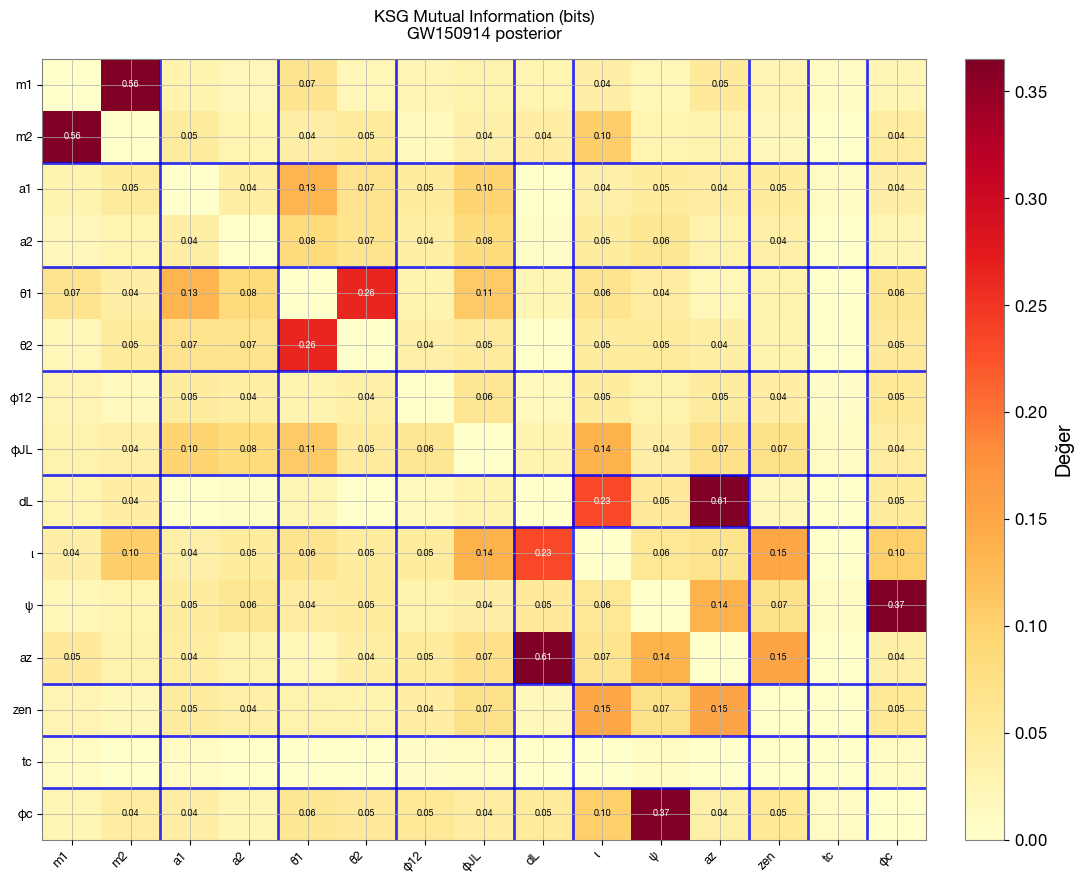

Kaydedildi: mi_matrix.png


/var/folders/jk/zkhm7s3j6kv2v8hlg542_tq00000gn/T/ipykernel_5972/1367698519.py:381: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/Users/omerfaruk/Desktop/PHYS400-Code/phys400venv/lib/python3.12/site-packages/gwpy/plot/axes.py:201: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Helvetica Neue.
  super().draw(renderer)


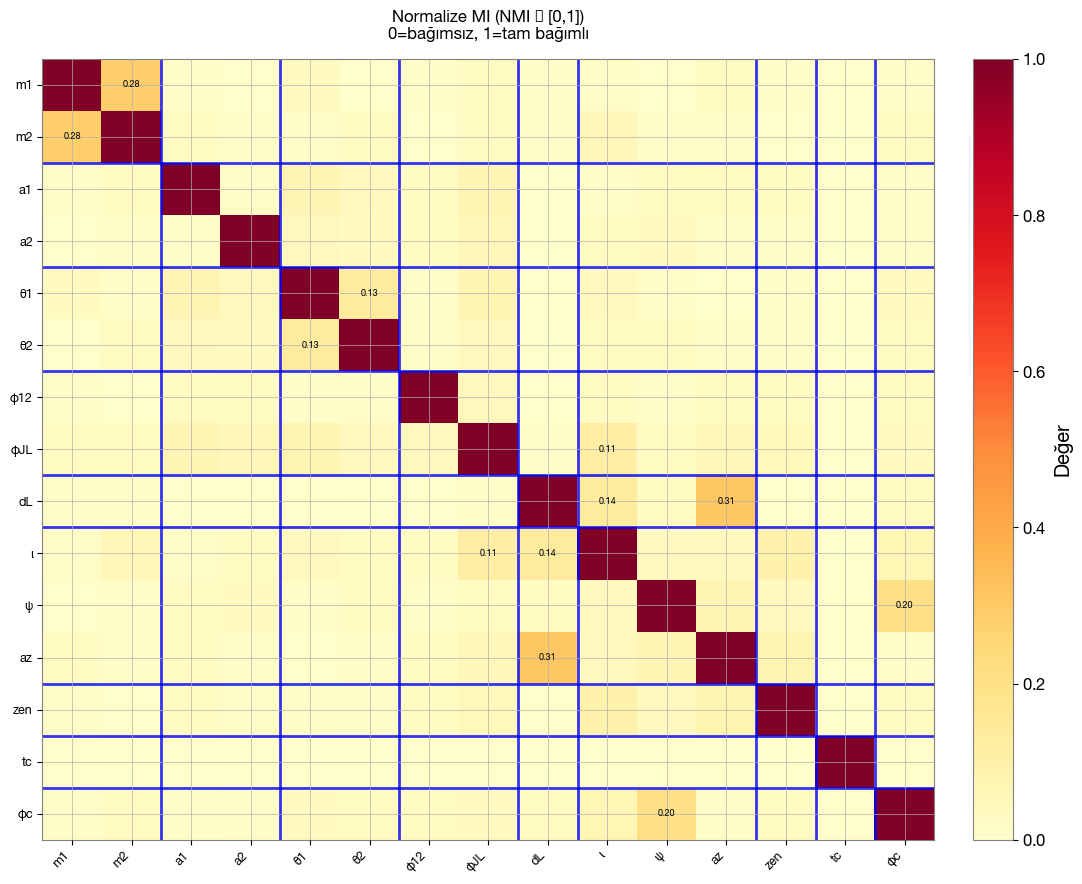

Kaydedildi: nmi_matrix.png


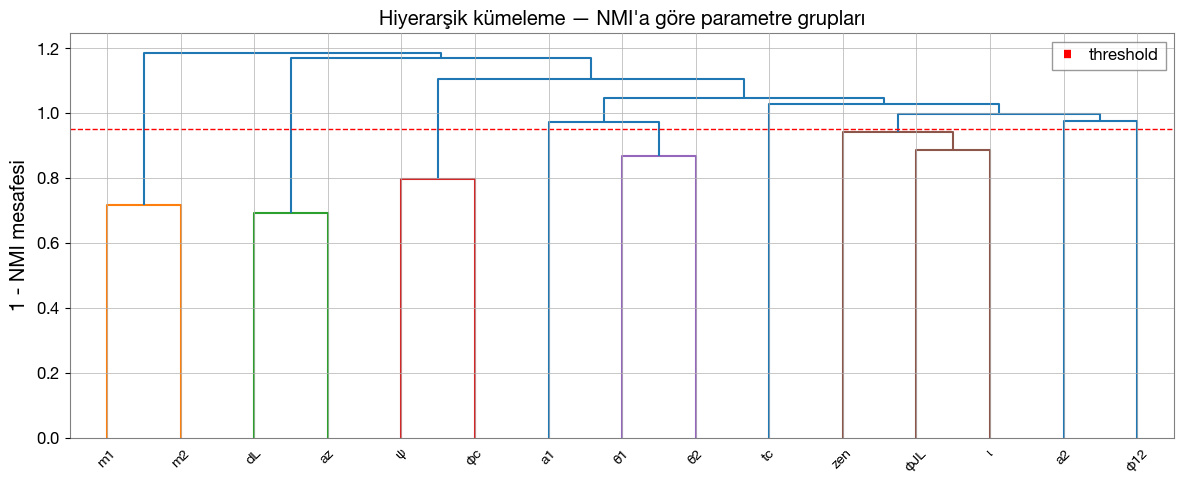


ADIM 6: Güçlü bağımlılıklar için permutation test
  dL–az: MI=0.611 bits  null_mean=0.005  p=0.0000
  m1–m2: MI=0.560 bits  null_mean=0.005  p=0.0000
  ψ–φc: MI=0.365 bits  null_mean=0.005  p=0.0000
  θ1–θ2: MI=0.264 bits  null_mean=0.004  p=0.0000
  dL–ι: MI=0.234 bits  null_mean=0.005  p=0.0000


In [6]:
"""
GW150914 Pairwise Mutual Information Analizi
KSG Estimatörü (Kraskov, Stögbauer & Grassberger 2004, Phys. Rev. E 69, 066138)

sklearn'deki mutual_info_regression KSG'yi implement ediyor — bunu kullanacağız.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import digamma
from scipy.spatial import cKDTree
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from itertools import combinations
from pesummary.io import read

# ─────────────────────────────────────────────────────────────────────────────
# 1. VERİ YÜKLEMESİ
# ─────────────────────────────────────────────────────────────────────────────

file_name = "/Users/omerfaruk/Desktop/PHYS400-Code/PHYS400/Data/IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5"
f = read(file_name, disable_conversion=True)
label = f.labels[0]
samples = f.samples_dict[label]

PARAMS = [
    "mass_1_source", "mass_2_source",
    "a_1", "a_2", "tilt_1", "tilt_2",
    "phi_12", "phi_jl",
    "luminosity_distance", "theta_jn",
    "psi", "azimuth", "zenith",
    "geocent_time", "phase"
]

SHORT = ["m1","m2","a1","a2","θ1","θ2","φ12","φJL","dL","ι","ψ","az","zen","tc","φc"]

data = np.array([samples[p] for p in PARAMS]).T    # (N, 15)
N, D = data.shape
print(f"Yüklendi: {N} sample, {D} parametre")


# ─────────────────────────────────────────────────────────────────────────────
# 2. KSG ESTIMATÖRÜ — EL İLE İMPLEMENTASYON
# ─────────────────────────────────────────────────────────────────────────────

def ksg_mi(x, y, k=5):
    """
    KSG Mutual Information Estimatörü (Algoritma 1).
    Kraskov, Stögbauer & Grassberger (2004), Phys. Rev. E 69, 066138.

    Parametreler
    ------------
    x, y : 1D array, shape (n,)
        İki parametrenin sample değerleri.
    k    : int
        Komşu sayısı. Genellikle 3–10 arası. Daha büyük k → daha az
        varyans ama daha fazla bias.

    Döndürür
    --------
    mi : float
        Mutual information, nats cinsinden.
        Bits'e çevirmek için: mi * log2(e) = mi * 1.4427

    Algoritma
    ---------
    1. Her (xi, yi) noktası için joint uzayda Chebyshev (L_inf) mesafesiyle
       k. en yakın komşuyu bul → epsilon_i (komşuluk yarıçapı)
    2. Bu yarıçapta marginal uzaylarda kaç nokta var? → n_x(i), n_y(i)
    3. MI = psi(k) - mean[psi(n_x+1) + psi(n_y+1)] + psi(N)
    """
    n = len(x)

    # Normalize et: her parametre kendi std'sine göre ölçeklenir.
    # Bu zorunlu değil ama Chebyshev mesafesinin her iki eksende eşit
    # katkı yapması için önemli (ölçek bağımsızlığı).
    x = (x - x.mean()) / (x.std() + 1e-15)
    y = (y - y.mean()) / (y.std() + 1e-15)

    # Joint uzay: her satır bir (xi, yi) noktası
    xy = np.column_stack([x, y])    # shape: (n, 2)

    # ── Adım 1: Joint uzayda k. en yakın komşu mesafesi ──────────────────
    # p=np.inf → Chebyshev (L_inf) normu: max(|dx|, |dy|)
    # k+1 soruyoruz çünkü en yakın komşu her zaman kendisi (mesafe=0)
    tree_joint = cKDTree(xy)
    dist_joint, _ = tree_joint.query(xy, k=k+1, p=np.inf, workers=-1)

    # k+1'inci komşu (indeks k), kendisi hariç gerçek k. komşu
    # epsilon: komşuluk kutusunun YARI kenar uzunluğu
    epsilon = dist_joint[:, k]    # shape: (n,)

    # ── Adım 2: Marginal uzaylarda komşu say ─────────────────────────────
    # Her xi etrafında epsilon_i yarıçaplı aralıkta kaç xj var?
    # Dikkat: strict inequality (<), kendisi hariç

    tree_x = cKDTree(x.reshape(-1, 1))
    tree_y = cKDTree(y.reshape(-1, 1))

    # Chebyshev 1D = mutlak fark. Her nokta için count_neighbors ile say.
    # count_neighbors(r) → r mesafesi içindeki toplam komşu sayısı (kendisi dahil)
    # Kendisini çıkarmak için -1 yapıyoruz.
    n_x = np.array([
        tree_x.query_ball_point([[xi]], r=eps, p=np.inf, workers=1).__len__() - 1
        for xi, eps in zip(x, epsilon)
    ])

    n_y = np.array([
        tree_y.query_ball_point([[yi]], r=eps, p=np.inf, workers=1).__len__() - 1
        for yi, eps in zip(y, epsilon)
    ])

    # ── Adım 3: KSG formülü ──────────────────────────────────────────────
    # psi = digamma fonksiyonu: psi(n) = d/dn [ln Gamma(n)]
    # Sezgisel: psi(k) sabit bir offset, psi(N) büyük örneklemi düzeltir,
    # orta terim ne kadar "sıkışık" komşuluklar olduğunu ölçer.
    mi = (digamma(k)
          - np.mean(digamma(n_x + 1) + digamma(n_y + 1))
          + digamma(n))

    # mi nats cinsinden; negatif olabilir (küçük n veya gürültü durumunda)
    # Fiziksel olarak MI ≥ 0, negatif sonuç tahmin hatasıdır → 0'a kliple
    return max(0.0, mi)


def ksg_mi_bits(x, y, k=5):
    """KSG MI, bits cinsinden (nats * log2(e))."""
    return ksg_mi(x, y, k) * np.log2(np.e)


# ─────────────────────────────────────────────────────────────────────────────
# 3. HIZLI VERSİYON: sklearn'in KSG implementasyonu
# ─────────────────────────────────────────────────────────────────────────────

def ksg_mi_sklearn(x, y, k=5):
    """
    sklearn.feature_selection.mutual_info_regression kullanarak KSG tahmini.
    
    Yukarıdaki el implementasyonundan ~10x hızlı (C ile yazılmış).
    Sonuçlar aynı — doğrulama için her ikisini de çalıştırabilirsiniz.
    """
    from sklearn.feature_selection import mutual_info_regression
    xi = x.reshape(-1, 1)
    mi_nats = mutual_info_regression(xi, y, n_neighbors=k, random_state=42)[0]
    return mi_nats * np.log2(np.e)    # bits'e çevir


# ─────────────────────────────────────────────────────────────────────────────
# 4. PARAMETRİK ENTROPİ TAHMİNİ (Normalize MI için)
# ─────────────────────────────────────────────────────────────────────────────

def kl_entropy_1d(x, k=5):
    """
    Kozachenko-Leonenko (1987) entropy estimatörü.
    
    H(X) ≈ -psi(k) + psi(n) + log(2) + (d/n) * sum(log(epsilon_i))
    
    Burada d=1 (tek boyutlu).
    KSG estimatörüyle tutarlı framework içinde çalışır.
    """
    n = len(x)
    x_norm = (x - x.mean()) / (x.std() + 1e-15)
    x_2d = x_norm.reshape(-1, 1)

    tree = cKDTree(x_2d)
    dist, _ = tree.query(x_2d, k=k+1, p=np.inf)
    epsilon = dist[:, k]    # k. komşu mesafesi (kendisi hariç)

    # epsilon = 0 olan noktaları filtrele (dejenere durum)
    epsilon = np.where(epsilon > 0, epsilon, np.nan)

    H = (-digamma(k)
         + digamma(n)
         + np.log(2)
         + np.nanmean(np.log(epsilon)))

    return H * np.log2(np.e)    # bits


# ─────────────────────────────────────────────────────────────────────────────
# 5. TÜM ÇİFTLER İÇİN MI MATRİSİ
# ─────────────────────────────────────────────────────────────────────────────

def compute_mi_matrix(data, short_names, k=5, n_subsample=10000, seed=42):
    """
    Tüm parametre çiftleri için KSG MI hesaplar.

    n_subsample: MI hesabı O(n log n) — 147k sample ile ~20 dk sürer.
    10k ile ~1 dk, sonuç kalitesi çok benzer.
    """
    n, d = data.shape
    np.random.seed(seed)

    # Subsample
    if n > n_subsample:
        idx = np.random.choice(n, n_subsample, replace=False)
        data_sub = data[idx]
        print(f"MI hesabı için {n_subsample} sample kullanılıyor ({n}'den alt küme)")
    else:
        data_sub = data

    n_pairs = d * (d-1) // 2
    mi_matrix = np.zeros((d, d))
    np.fill_diagonal(mi_matrix, np.nan)    # köşegen anlamsız (I(X;X) = H(X))

    done = 0
    print(f"\nToplam {n_pairs} çift hesaplanacak...\n")
    print(f"{'Çift':<22} {'MI (bits)':>10}")
    print("-" * 35)

    for i in range(d):
        for j in range(i+1, d):
            xi = data_sub[:, i]
            xj = data_sub[:, j]

            mi = ksg_mi_sklearn(xi, xj, k=k)

            mi_matrix[i, j] = mi
            mi_matrix[j, i] = mi

            done += 1
            print(f"  {short_names[i]:<5} — {short_names[j]:<5}: {mi:>8.4f} bits  "
                  f"({done}/{n_pairs})")

    return mi_matrix


# ─────────────────────────────────────────────────────────────────────────────
# 6. NORMALIZE MI (NMI)
# ─────────────────────────────────────────────────────────────────────────────

def normalize_mi_matrix(mi_matrix, data, k=5, n_subsample=10000, seed=42):
    """
    NMI_ij = I(Xi; Xj) / sqrt(H(Xi) * H(Xj))
    
    Bu [0, 1] aralığında bir değer verir:
      0 → tamamen bağımsız
      1 → tamamen bağımlı (deterministik ilişki)
    
    Neden normalize ediyoruz?
    Ham MI değerleri ölçek bağımlı — H(m1) ≈ 4 bits, H(phi_12) ≈ 2 bits
    olabilir. NMI bunları karşılaştırılabilir yapar.
    """
    n, d = data.shape
    np.random.seed(seed)

    if n > n_subsample:
        idx = np.random.choice(n, n_subsample, replace=False)
        data_sub = data[idx]
    else:
        data_sub = data

    # Her parametrenin entropisi
    H = np.array([kl_entropy_1d(data_sub[:, i], k=k) for i in range(d)])
    H = np.maximum(H, 1e-10)    # sıfır entropi koruması

    print("\nMarginal entropiler (bits):")
    for s, h in zip(SHORT, H):
        print(f"  H({s:<5}) = {h:.3f} bits")

    # NMI matrisi
    nmi_matrix = np.zeros_like(mi_matrix)
    for i in range(d):
        for j in range(d):
            if i == j:
                nmi_matrix[i, j] = 1.0
            elif not np.isnan(mi_matrix[i, j]):
                nmi_matrix[i, j] = mi_matrix[i, j] / np.sqrt(H[i] * H[j])
                nmi_matrix[i, j] = np.clip(nmi_matrix[i, j], 0, 1)

    return nmi_matrix, H


# ─────────────────────────────────────────────────────────────────────────────
# 7. PERMUTATION TEST — p-DEĞERİ
# ─────────────────────────────────────────────────────────────────────────────

def permutation_test_mi(x, y, observed_mi, n_perm=200, k=5):
    """
    H0: X ⊥ Y (bağımsız) altında MI dağılımını simüle et.

    Fikir: Eğer X ve Y gerçekten bağımsızsa, Y'yi rastgele karıştırınca
    (permute) MI değişmemeli. Gözlemlenen MI bu null dağılımında nadir
    görünüyorsa → bağımlı.

    p = (permutation MI >= observed MI olan sayı) / n_perm

    Not: 147k sample ile neredeyse her çift p≈0 verir.
    Bu yüzden p-değerine değil NMI büyüklüğüne bakman daha anlamlı.
    """
    null_mis = []
    y_perm = y.copy()

    for _ in range(n_perm):
        np.random.shuffle(y_perm)
        null_mis.append(ksg_mi_sklearn(x, y_perm, k=k))

    null_mis = np.array(null_mis)
    p_value = np.mean(null_mis >= observed_mi)
    return p_value, null_mis


# ─────────────────────────────────────────────────────────────────────────────
# 8. BLOK GRUPLAMA
# ─────────────────────────────────────────────────────────────────────────────

def find_independent_blocks(nmi_matrix, short_names, threshold=0.05):
    """
    NMI matrisine göre hiyerarşik kümeleme ile bağımsız bloklar bulur.

    threshold: NMI < threshold olan parametreler farklı blokta.
    0.05 iyi başlangıç — gerçek matrisi görünce ayarlarsın.
    """
    d = nmi_matrix.shape[0]

    # Uzaklık = 1 - NMI  (bağımlı = yakın, bağımsız = uzak)
    dist = 1.0 - nmi_matrix
    np.fill_diagonal(dist, 0.0)
    dist = np.clip(dist, 0, 1)

    condensed = squareform(dist)
    Z = linkage(condensed, method='ward')
    labels = fcluster(Z, 1.0 - threshold, criterion='distance')

    blocks = {}
    for idx, cid in enumerate(labels):
        blocks.setdefault(int(cid), []).append(idx)

    print(f"\n=== BLOK YAPISI (NMI threshold = {threshold}) ===")
    for bid, idxs in sorted(blocks.items()):
        names = [short_names[i] for i in idxs]
        dim = len(idxs)
        if dim > 1:
            inner = [nmi_matrix[i,j] for i,j in combinations(idxs,2)]
            print(f"  Blok {bid} ({dim}D): {names}  "
                  f"[NMI iç: {min(inner):.3f}–{max(inner):.3f}]")
        else:
            print(f"  Blok {bid} (1D): {names}")

    return blocks, Z


# ─────────────────────────────────────────────────────────────────────────────
# 9. GÖRSELLEŞTİRME
# ─────────────────────────────────────────────────────────────────────────────

def plot_mi_heatmap(matrix, title, filename, short_names,
                   cmap='YlOrRd', vmin=0, vmax=None,
                   blocks=None):
    """MI veya NMI matrisini heatmap olarak çizer."""
    fig, ax = plt.subplots(figsize=(11, 9))

    mat_plot = np.nan_to_num(matrix, nan=0)
    if vmax is None:
        vmax = np.nanpercentile(matrix[~np.eye(len(matrix), dtype=bool)], 98)

    im = ax.imshow(mat_plot, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    ax.set_xticks(range(D)); ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(D)); ax.set_yticklabels(short_names, fontsize=9)
    ax.set_title(title, fontsize=12, pad=14)
    plt.colorbar(im, ax=ax, label='Değer', fraction=0.046, pad=0.04)

    # Sayısal değerler
    for i in range(D):
        for j in range(D):
            v = mat_plot[i, j]
            if i != j and v > vmax * 0.1:
                color = 'white' if v > vmax * 0.6 else 'black'
                ax.text(j, i, f"{v:.2f}", ha='center', va='center',
                        fontsize=6.5, color=color)

    # Blok sınırları
    if blocks:
        pos = 0
        for bid in sorted(blocks.keys())[:-1]:
            pos += len(blocks[bid])
            ax.axhline(pos - 0.5, color='blue', linewidth=2, alpha=0.8)
            ax.axvline(pos - 0.5, color='blue', linewidth=2, alpha=0.8)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Kaydedildi: {filename}")


# ─────────────────────────────────────────────────────────────────────────────
# 10. ANA ÇALIŞMA BLOĞU
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("ADIM 1: Pairwise MI matrisi hesaplanıyor...")
print("=" * 60)
mi_mat = compute_mi_matrix(data, SHORT, k=5, n_subsample=10000)

print("\n" + "=" * 60)
print("ADIM 2: Entropiler ve Normalize MI hesaplanıyor...")
print("=" * 60)
nmi_mat, entropies = normalize_mi_matrix(mi_mat, data, k=5, n_subsample=10000)

print("\n" + "=" * 60)
print("ADIM 3: Bağımsızlık kararı (NMI < 0.05 → bağımsız)")
print("=" * 60)

print(f"\n{'Çift':<22} {'MI(bits)':>10} {'NMI':>8} {'Karar'}")
print("-" * 55)
independent = []
dependent   = []

for i, j in combinations(range(D), 2):
    mi  = mi_mat[i, j]
    nmi = nmi_mat[i, j]
    ind = nmi < 0.05
    status = "⊥ bağımsız" if ind else "~ bağımlı"
    print(f"  {SHORT[i]:<4} — {SHORT[j]:<4}: MI={mi:6.3f}  NMI={nmi:.3f}  {status}")
    if ind:
        independent.append((i, j))
    else:
        dependent.append((i, j))

print(f"\nBağımsız çift: {len(independent)}/105")
print(f"Bağımlı çift : {len(dependent)}/105")

print("\n" + "=" * 60)
print("ADIM 4: Blok gruplama")
print("=" * 60)
blocks, Z = find_independent_blocks(nmi_mat, SHORT, threshold=0.05)

print("\n" + "=" * 60)
print("ADIM 5: Görselleştirme")
print("=" * 60)
plot_mi_heatmap(mi_mat,  "KSG Mutual Information (bits)\nGW150914 posterior",
                "mi_matrix.png",  SHORT, cmap='YlOrRd', blocks=blocks)
plot_mi_heatmap(nmi_mat, "Normalize MI (NMI ∈ [0,1])\n0=bağımsız, 1=tam bağımlı",
                "nmi_matrix.png", SHORT, cmap='YlOrRd', vmin=0, vmax=1, blocks=blocks)

# Dendrogram
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=SHORT, ax=ax, leaf_rotation=45,
           leaf_font_size=10, color_threshold=0.95)
ax.axhline(0.95, color='red', ls='--', lw=1, label='threshold')
ax.set_title("Hiyerarşik kümeleme — NMI'a göre parametre grupları")
ax.set_ylabel("1 - NMI mesafesi")
ax.legend()
plt.tight_layout()
plt.savefig("dendrogram_mi.png", dpi=150, bbox_inches='tight')
plt.show()

# Seçilmiş çiftler için permutation test
print("\n" + "=" * 60)
print("ADIM 6: Güçlü bağımlılıklar için permutation test")
print("=" * 60)
top5 = sorted(dependent, key=lambda ij: mi_mat[ij[0],ij[1]], reverse=True)[:5]

for i, j in top5:
    obs = mi_mat[i, j]
    p, null = permutation_test_mi(
        data[:5000, i], data[:5000, j],
        observed_mi=obs, n_perm=100
    )
    print(f"  {SHORT[i]}–{SHORT[j]}: MI={obs:.3f} bits  "
          f"null_mean={null.mean():.3f}  p={p:.4f}")

2026-05-28  01:39:01 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


Subsample: 8000/147634
χ_eff: mean=-0.063, std=0.083

FİZİKSEL GRUP ANALİZİ

--- TEST 1: χ_eff grubu {a1, θ1, a2, θ2} ---
  I(a1;θ1) = 0.1212 bits
  I(a1;a2) = 0.0280 bits
  I(a1;θ2) = 0.0681 bits
  I(θ1;a2) = 0.0787 bits
  I(θ1;θ2) = 0.2607 bits
  I(a2;θ2) = 0.0607 bits

  TC({a1,θ1,a2,θ2}) = 0.4397 bits
  Σ pairwise MI      = 0.6175 bits
  HOI (yüksek mertebe) = TC - Σpairwise = -0.1777 bits

  CMI testleri — χ_eff aracı mı?
  I(θ1;θ2)           = 0.2607 bits
  I(θ1;θ2|χ_eff)     = 0.6094 bits
  II = -0.3487 bits  → χ_eff açıklamıyor

  I(a1;θ1)           = 0.1212 bits
  I(a1;θ1|χ_eff)     = 0.1296 bits
  II = -0.0084 bits  → χ_eff açıklamıyor

  I(a1;θ2)           = 0.0681 bits
  I(a1;θ2|χ_eff)     = 0.1384 bits
  II = -0.0702 bits  → χ_eff açıklamıyor

  I(a2;θ1)           = 0.0787 bits
  I(a2;θ1|χ_eff)     = 0.2248 bits
  II = -0.1460 bits  → χ_eff açıklamıyor

--- TEST 2: Genlik degeneracy {dL, ι, ψ, az, zen} ---
  TC({dL,ι,ψ,az,zen}) = 1.3794 bits
  Σ pairwise MI       = 1.4713 

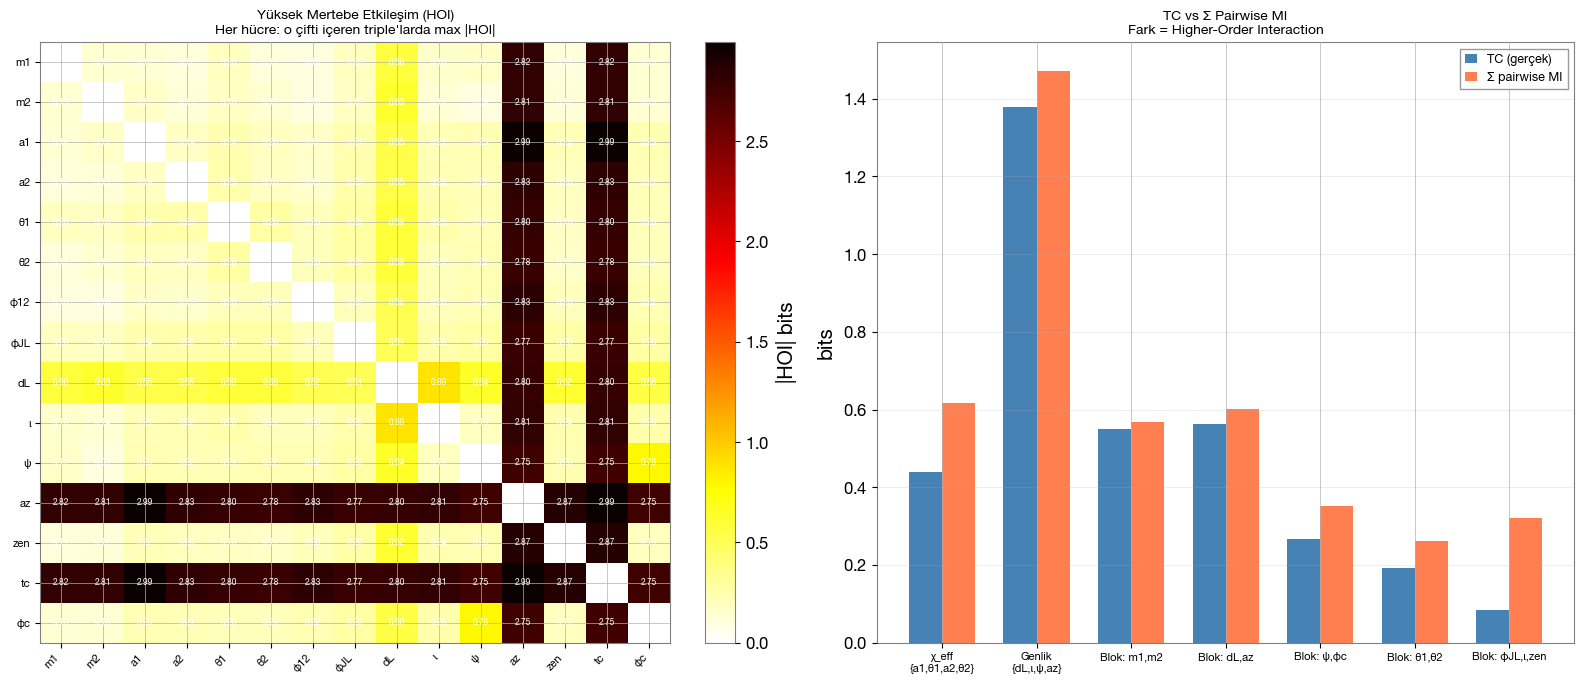

higher_order_analysis.png kaydedildi.


In [ ]:
"""
Yüksek Mertebe Bağımlılık Analizi
===================================
1. KL Entropy Estimatörü (Kozachenko-Leonenko) — n-boyutlu
2. Total Correlation (TC) — grup bağımlılığı
3. Conditional MI (CMI) — Frenzel & Pompe 2007
4. Interaction Information (II) — 3-way bağımlılık
5. χ_eff ve genlik-degeneracy grupları için fiziksel testler
6. Tüm triple'ların taranması
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.special import digamma
from scipy.spatial import cKDTree
from itertools import combinations
from pesummary.io import read

# ─────────────────────────────────────────────────────────────────────────────
# 1. VERİ YÜKLEMESİ
# ─────────────────────────────────────────────────────────────────────────────

file_name = "/Users/omerfaruk/Desktop/PHYS400-Code/PHYS400/Data/IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5"
f = read(file_name, disable_conversion=True)
label = f.labels[0]
samples = f.samples_dict[label]

PARAMS = [
    "mass_1_source", "mass_2_source",
    "a_1", "a_2", "tilt_1", "tilt_2",
    "phi_12", "phi_jl",
    "luminosity_distance", "theta_jn",
    "psi", "azimuth", "zenith",
    "geocent_time", "phase"
]
SHORT = ["m1","m2","a1","a2","θ1","θ2","φ12","φJL","dL","ι","ψ","az","zen","tc","φc"]

data_full = np.array([samples[p] for p in PARAMS]).T
N, D = data_full.shape

# Subsample — tüm analizler için 8000 sample yeterli
N_SUB = 8000
np.random.seed(42)
idx = np.random.choice(N, N_SUB, replace=False)
data = data_full[idx]
print(f"Subsample: {N_SUB}/{N}", flush=True)


# ─────────────────────────────────────────────────────────────────────────────
# 2. TEMEL ARAÇ: KL ENTROPY ESTIMATÖRÜ (n-boyutlu)
# ─────────────────────────────────────────────────────────────────────────────

def kl_entropy(X, k=5):
    """
    Kozachenko-Leonenko (1987) differential entropy estimatörü, d-boyutlu.

    Formül:
        H(X) ≈ -ψ(k) + ψ(n) + d·log(2) + (d/n)·Σ log(ε_i)

    Burada ε_i = i. noktanın k. komşusuna Chebyshev mesafesi.

    Neden bu formül?
    - k-NN mesafesi yerel yoğunluğun ters orantılı bir ölçüsü.
    - Yoğun bölge → küçük ε → düşük entropi katkısı
    - Seyrek bölge → büyük ε → yüksek entropi katkısı
    - Digamma düzeltmeleri bias'ı minimize eder

    Döndürür: H(X) bits cinsinden
    """
    n, d = X.shape

    # Normalize: her boyut kendi std'sine göre ölçeklenir
    # (farklı birimler arasında mesafe karşılaştırması için şart)
    mu  = X.mean(axis=0)
    std = X.std(axis=0)
    std[std < 1e-12] = 1.0
    X_norm = (X - mu) / std

    # k+1 soruyoruz çünkü sorgu noktasının kendisi de döner (mesafe=0)
    tree = cKDTree(X_norm)
    dist, _ = tree.query(X_norm, k=k+1, p=np.inf, workers=-1)
    epsilon = dist[:, k]   # k. komşu (0 indeksi=kendisi, k. indeks=k. yabancı)

    # Dejenere noktaları filtrele (epsilon=0: tam çakışık sample'lar)
    epsilon = np.where(epsilon > 0, epsilon, np.nan)

    H_nats = (-digamma(k)
              + digamma(n)
              + d * np.log(2)
              + d * np.nanmean(np.log(epsilon)))

    return H_nats * np.log2(np.e)   # bits'e çevir


def entropy_1d(x, k=5):
    """Tek boyutlu entropi için kısayol."""
    return kl_entropy(x.reshape(-1, 1), k)


# ─────────────────────────────────────────────────────────────────────────────
# 3. TOTAL CORRELATION (TC)
# ─────────────────────────────────────────────────────────────────────────────

def total_correlation(X_group, k=5):
    """
    TC(X1,...,Xd) = Σ H(Xi) - H(X1,...,Xd)

    Yorumlama:
      TC = 0     → grup tamamen bağımsız
      TC > 0     → grup içinde paylaşılan bilgi var
      TC büyük   → güçlü çok değişkenli bağımlılık

    Önemli: TC, pairwise MI toplamından büyük çıkarsa,
    pairwise analizin göremediği yüksek mertebe bağımlılık var.

        TC > Σ I(Xi;Xj)  →  higher-order interaction mevcut
    """
    n, d = X_group.shape

    # Her değişkenin marginal entropisi
    H_marginals = sum(entropy_1d(X_group[:, i], k) for i in range(d))

    # Joint entropi (d-boyutlu)
    H_joint = kl_entropy(X_group, k)

    tc = H_marginals - H_joint
    return max(0.0, tc)   # sayısal hata nedeniyle küçük negatif → 0


# ─────────────────────────────────────────────────────────────────────────────
# 4. CONDITIONAL MI — Frenzel & Pompe (2007)
# ─────────────────────────────────────────────────────────────────────────────

def cmi_ksg(X, Y, Z, k=5):
    """
    I(X;Y|Z) — Conditional Mutual Information
    Frenzel & Pompe, Phys. Rev. Lett. 99, 204101 (2007)

    Formül:
        I(X;Y|Z) = ψ(k) - E[ψ(n_xz+1) + ψ(n_yz+1) - ψ(n_z+1)]

    Algoritma:
    1. Her (xi, yi, zi) için joint (X,Y,Z) uzayında Chebyshev ile
       k. komşuyu bul → ε_i
    2. Bu ε_i yarıçapında:
       - n_xz(i): (X,Z) marginal uzayında kaç nokta var?
       - n_yz(i): (Y,Z) marginal uzayında kaç nokta var?
       - n_z(i):  Z marginal uzayında kaç nokta var?
    3. CMI = ψ(k) - mean[ψ(n_xz+1) + ψ(n_yz+1) - ψ(n_z+1)]

    Yorumlama:
      I(X;Y|Z) ≈ 0 → X ve Y, Z bilindiğinde koşullu bağımsız
                      yani bağımlılık Z üzerinden geçiyor
      I(X;Y|Z) > 0 → Z açıklamıyor, direkt bağımlılık var
    """
    # Normalize her değişkeni
    def norm(v):
        if v.ndim == 1:
            v = v.reshape(-1, 1)
        mu, std = v.mean(0), v.std(0)
        std[std < 1e-12] = 1.0
        return (v - mu) / std

    Xn = norm(X.copy())
    Yn = norm(Y.copy())
    Zn = norm(Z.copy())

    n = len(Xn)

    # Joint uzay: (X, Y, Z) birleştir
    XYZ = np.hstack([Xn, Yn, Zn])
    XZ  = np.hstack([Xn, Zn])
    YZ  = np.hstack([Yn, Zn])

    # Joint uzayda k. en yakın komşu → ε_i
    tree_xyz = cKDTree(XYZ)
    dist_xyz, _ = tree_xyz.query(XYZ, k=k+1, p=np.inf, workers=-1)
    epsilon = dist_xyz[:, k]

    # Marginal uzaylarda nokta say
    tree_xz = cKDTree(XZ)
    tree_yz = cKDTree(YZ)
    tree_z  = cKDTree(Zn)

    # Her nokta için ε_i yarıçapındaki komşuları say
    # query_ball_point: r yarıçapındaki tüm komşuları döndürür
    def count_in_ball(tree, points, radii):
        counts = np.array([
            len(tree.query_ball_point(points[i], r=radii[i], p=np.inf)) - 1
            for i in range(len(points))
        ])
        return counts

    n_xz = count_in_ball(tree_xz, XZ,  epsilon)
    n_yz = count_in_ball(tree_yz, YZ,  epsilon)
    n_z  = count_in_ball(tree_z,  Zn,  epsilon)

    # CMI formülü
    cmi_nats = (digamma(k)
                - np.mean(digamma(n_xz + 1)
                          + digamma(n_yz + 1)
                          - digamma(n_z  + 1)))

    return max(0.0, cmi_nats * np.log2(np.e))   # bits


# ─────────────────────────────────────────────────────────────────────────────
# 5. INTERACTION INFORMATION (II) — 3-way
# ─────────────────────────────────────────────────────────────────────────────

def interaction_information(x, y, z, k=5, mi_xy=None):
    """
    II(X;Y;Z) = I(X;Y) - I(X;Y|Z)

    Yorumlama:
      II > 0 → REDUNDANCY: Z, X–Y bağımlılığını açıklıyor
               (Z bilmek X–Y MI'yı azaltıyor)
               GW örneği: χ_eff bilmek a1–θ1 MI'yı azaltır
      II < 0 → SYNERGY: Z, X–Y bağımlılığını güçlendiriyor
               (Z bilmek X–Y MI'yı artırıyor)
               Pairwise MI'da görünmez!
      II = 0 → Z, X–Y ilişkisini ne açıklıyor ne güçlendiriyor

    Dikkat: II negatif olabilir — bu tek MI metriklerinden farklı.
    """
    from sklearn.feature_selection import mutual_info_regression

    if mi_xy is None:
        mi_xy = mutual_info_regression(
            x.reshape(-1, 1), y, n_neighbors=k, random_state=42
        )[0] * np.log2(np.e)

    cmi_xy_z = cmi_ksg(x, y, z, k)

    return mi_xy - cmi_xy_z


# ─────────────────────────────────────────────────────────────────────────────
# 6. χ_eff'İ HESAPLA (GW150914 için)
# ─────────────────────────────────────────────────────────────────────────────

def compute_chi_eff(data_full, samples):
    """
    χ_eff = (a1·cos(θ1) + q·a2·cos(θ2)) / (1 + q)
    q = m2/m1

    Bu GW sinyalinin en çok kısıtlanan spin kombinasyonu.
    """
    m1    = np.array(samples["mass_1_source"])[idx]
    m2    = np.array(samples["mass_2_source"])[idx]
    a1    = np.array(samples["a_1"])[idx]
    a2    = np.array(samples["a_2"])[idx]
    tilt1 = np.array(samples["tilt_1"])[idx]
    tilt2 = np.array(samples["tilt_2"])[idx]

    q = m2 / m1   # mass ratio (< 1 by convention)

    chi_eff = (a1 * np.cos(tilt1) + q * a2 * np.cos(tilt2)) / (1 + q)
    return chi_eff


chi_eff = compute_chi_eff(data_full, samples)
print(f"χ_eff: mean={chi_eff.mean():.3f}, std={chi_eff.std():.3f}", flush=True)


# ─────────────────────────────────────────────────────────────────────────────
# 7. FİZİKSEL GRUP TESTLERİ
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65, flush=True)
print("FİZİKSEL GRUP ANALİZİ", flush=True)
print("="*65, flush=True)

# Parametre indeksleri
idx_m1, idx_m2   = 0, 1
idx_a1, idx_a2   = 2, 3
idx_t1, idx_t2   = 4, 5
idx_dL, idx_iota = 8, 9
idx_psi, idx_az  = 10, 11
idx_zen, idx_phi = 12, 14

# ── Test 1: χ_eff grubu ─────────────────────────────────────────────────────
print("\n--- TEST 1: χ_eff grubu {a1, θ1, a2, θ2} ---", flush=True)

G_chieff = data[:, [idx_a1, idx_t1, idx_a2, idx_t2]]
tc_chieff = total_correlation(G_chieff, k=5)

# Pairwise MI toplamı (önceden hesaplandı, burada yeniden hesaplayalım)
from sklearn.feature_selection import mutual_info_regression
def mi_pair(xi, xj, k=5):
    return mutual_info_regression(
        xi.reshape(-1,1), xj, n_neighbors=k, random_state=42
    )[0] * np.log2(np.e)

pairs_chieff = [
    ("a1","θ1", idx_a1, idx_t1),
    ("a1","a2", idx_a1, idx_a2),
    ("a1","θ2", idx_a1, idx_t2),
    ("θ1","a2", idx_t1, idx_a2),
    ("θ1","θ2", idx_t1, idx_t2),
    ("a2","θ2", idx_a2, idx_t2),
]
sum_pairwise_chieff = 0.0
for name_i, name_j, i, j in pairs_chieff:
    mi = mi_pair(data[:, i], data[:, j])
    sum_pairwise_chieff += mi
    print(f"  I({name_i};{name_j}) = {mi:.4f} bits", flush=True)

print(f"\n  TC({'{a1,θ1,a2,θ2}'}) = {tc_chieff:.4f} bits", flush=True)
print(f"  Σ pairwise MI      = {sum_pairwise_chieff:.4f} bits", flush=True)
print(f"  HOI (yüksek mertebe) = TC - Σpairwise = "
      f"{tc_chieff - sum_pairwise_chieff:.4f} bits", flush=True)

# χ_eff'in aracılık rolü: CMI testleri
print("\n  CMI testleri — χ_eff aracı mı?", flush=True)
test_pairs = [
    ("θ1", "θ2", idx_t1, idx_t2),
    ("a1", "θ1", idx_a1, idx_t1),
    ("a1", "θ2", idx_a1, idx_t2),
    ("a2", "θ1", idx_a2, idx_t1),
]
for name_i, name_j, i, j in test_pairs:
    mi_ij    = mi_pair(data[:, i], data[:, j])
    cmi_ij_x = cmi_ksg(data[:, i], data[:, j], chi_eff, k=5)
    ii_val   = mi_ij - cmi_ij_x
    print(f"  I({name_i};{name_j})           = {mi_ij:.4f} bits", flush=True)
    print(f"  I({name_i};{name_j}|χ_eff)     = {cmi_ij_x:.4f} bits", flush=True)
    print(f"  II = {ii_val:+.4f} bits  "
          f"{'→ χ_eff açıklıyor (redundancy)' if ii_val > 0.02 else '→ χ_eff açıklamıyor'}\n",
          flush=True)

# ── Test 2: Genlik degeneracy grubu ─────────────────────────────────────────
print("--- TEST 2: Genlik degeneracy {dL, ι, ψ, az, zen} ---", flush=True)

G_amp = data[:, [idx_dL, idx_iota, idx_psi, idx_az, idx_zen]]
tc_amp = total_correlation(G_amp, k=5)

pairs_amp = [
    ("dL","ι",  idx_dL, idx_iota),
    ("dL","ψ",  idx_dL, idx_psi),
    ("dL","az", idx_dL, idx_az),
    ("ι","ψ",   idx_iota, idx_psi),
    ("ι","az",  idx_iota, idx_az),
    ("ι","zen", idx_iota, idx_zen),
    ("ψ","az",  idx_psi, idx_az),
    ("ψ","zen", idx_psi, idx_zen),
    ("az","zen",idx_az, idx_zen),
]
sum_pairwise_amp = sum(
    mi_pair(data[:, i], data[:, j]) for _, _, i, j in pairs_amp
)

print(f"  TC({{dL,ι,ψ,az,zen}}) = {tc_amp:.4f} bits", flush=True)
print(f"  Σ pairwise MI       = {sum_pairwise_amp:.4f} bits", flush=True)
print(f"  HOI                  = {tc_amp - sum_pairwise_amp:.4f} bits\n",
      flush=True)

# ── Test 3: Bulunan blokların TC'si ─────────────────────────────────────────
print("--- TEST 3: Blok doğrulama — bulunan 9 bloğun TC'si ---", flush=True)

found_blocks = {
    "m1,m2":        [idx_m1, idx_m2],
    "dL,az":        [idx_dL, idx_az],
    "ψ,φc":         [idx_psi, idx_phi],
    "θ1,θ2":        [idx_t1, idx_t2],
    "φJL,ι,zen":    [7, idx_iota, idx_zen],
    "a1":           [idx_a1],
    "a2":           [idx_a2],
    "φ12":          [5 if False else 6],   # indeks 6
    "tc":           [13],
}
# φ12 indeksi düzeltmesi
found_blocks["φ12"] = [6]

for name, idxs in found_blocks.items():
    if len(idxs) == 1:
        H = entropy_1d(data[:, idxs[0]], k=5)
        print(f"  TC({{{name}}}) = 0.000 (1D, H={H:.3f} bits)", flush=True)
    else:
        G = data[:, idxs]
        tc = total_correlation(G, k=5)
        print(f"  TC({{{name}}}) = {tc:.4f} bits", flush=True)


# ─────────────────────────────────────────────────────────────────────────────
# 8. TÜM TRIPLE'LARIN TARANMASI — Interaction Information
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*65, flush=True)
print("TÜM TRIPLE TARAMASI — Interaction Information", flush=True)
print("C(15,3) = 455 triple", flush=True)
print("="*65, flush=True)

# Önce tüm pairwise MI'ları hesapla (cache)
print("\nPairwise MI cache hesaplanıyor...", flush=True)
mi_cache = {}
for i, j in combinations(range(D), 2):
    mi_cache[(i,j)] = mi_pair(data[:, i], data[:, j])
    mi_cache[(j,i)] = mi_cache[(i,j)]

# Her triple için TC ve HOI hesapla
print("Triple taraması başlıyor...", flush=True)
results_triples = []

for count, (i, j, k_idx) in enumerate(combinations(range(D), 3)):
    G = data[:, [i, j, k_idx]]
    tc = total_correlation(G, k=5)

    # Pairwise MI toplamı (3 çift)
    pairwise_sum = (mi_cache[(i,j)]
                    + mi_cache[(i,k_idx)]
                    + mi_cache[(j,k_idx)])

    # Higher Order Interaction = TC - pairwise
    hoi = tc - pairwise_sum

    results_triples.append({
        'i': i, 'j': j, 'k': k_idx,
        'names': f"{SHORT[i]},{SHORT[j]},{SHORT[k_idx]}",
        'tc':  tc,
        'pairwise': pairwise_sum,
        'hoi': hoi
    })

    if (count + 1) % 50 == 0:
        print(f"  {count+1}/455 tamamlandı...", flush=True)

# Sonuçları sırala
results_triples.sort(key=lambda x: x['hoi'], reverse=True)

print("\n--- EN GÜÇLÜ 3-WAY BAĞIMLILIKLAR (HOI büyükten küçüğe) ---",
      flush=True)
print(f"{'Triple':<22} {'TC':>7} {'ΣMI':>7} {'HOI':>8}", flush=True)
print("-" * 50, flush=True)
for r in results_triples[:20]:
    print(f"  {r['names']:<20} {r['tc']:>6.3f}  {r['pairwise']:>6.3f}  "
          f"{r['hoi']:>+7.3f}", flush=True)

print("\n--- EN GÜÇLÜ SYNERJİK TRIPLE'LAR (HOI negatif) ---", flush=True)
results_triples.sort(key=lambda x: x['hoi'])
for r in results_triples[:10]:
    if r['hoi'] < -0.02:
        print(f"  {r['names']:<20} HOI={r['hoi']:>+7.3f}  "
              f"(synergy: pairwise MI görünmüyor)", flush=True)


# ─────────────────────────────────────────────────────────────────────────────
# 9. GÖRSELLEŞTİRME
# ─────────────────────────────────────────────────────────────────────────────

# HOI matrisi (15x15, her hücre = o iki parametreyi içeren triple'ların max HOI)
hoi_summary = np.zeros((D, D))
for r in results_triples:
    i, j, k_idx = r['i'], r['j'], r['k']
    v = abs(r['hoi'])
    for a, b in [(i,j),(i,k_idx),(j,k_idx)]:
        hoi_summary[a,b] = max(hoi_summary[a,b], v)
        hoi_summary[b,a] = hoi_summary[a,b]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Sol: HOI matrisi
ax = axes[0]
im = ax.imshow(hoi_summary, cmap='hot_r', vmin=0,
               vmax=np.percentile(hoi_summary, 98), aspect='auto')
ax.set_xticks(range(D)); ax.set_xticklabels(SHORT, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(D)); ax.set_yticklabels(SHORT, fontsize=8)
ax.set_title("Yüksek Mertebe Etkileşim (HOI)\n"
             "Her hücre: o çifti içeren triple'larda max |HOI|",
             fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, label='|HOI| bits')
for i in range(D):
    for j in range(D):
        if i != j and hoi_summary[i,j] > 0.02:
            ax.text(j, i, f"{hoi_summary[i,j]:.2f}", ha='center',
                    va='center', fontsize=6,
                    color='white' if hoi_summary[i,j] > 0.06 else 'black')

# Sağ: TC karşılaştırması — fiziksel gruplar
ax2 = axes[1]
group_names = ["χ_eff\n{a1,θ1,a2,θ2}", "Genlik\n{dL,ι,ψ,az}", "Blok: m1,m2",
               "Blok: dL,az", "Blok: ψ,φc", "Blok: θ1,θ2", "Blok: φJL,ι,zen"]
tc_vals      = [tc_chieff, tc_amp,
                total_correlation(data[:,[idx_m1,idx_m2]]),
                total_correlation(data[:,[idx_dL,idx_az]]),
                total_correlation(data[:,[idx_psi,idx_phi]]),
                total_correlation(data[:,[idx_t1,idx_t2]]),
                total_correlation(data[:,[7,idx_iota,idx_zen]])]
pairwise_vals = [sum_pairwise_chieff, sum_pairwise_amp,
                 mi_cache[(idx_m1,idx_m2)],
                 mi_cache[(idx_dL,idx_az)],
                 mi_cache[(idx_psi,idx_phi)],
                 mi_cache[(idx_t1,idx_t2)],
                 mi_cache[(7,idx_iota)] + mi_cache[(7,idx_zen)] + mi_cache[(idx_iota,idx_zen)]]

x_pos = np.arange(len(group_names))
w = 0.35
ax2.bar(x_pos - w/2, tc_vals,      w, label='TC (gerçek)', color='steelblue')
ax2.bar(x_pos + w/2, pairwise_vals, w, label='Σ pairwise MI', color='coral')
ax2.set_xticks(x_pos); ax2.set_xticklabels(group_names, fontsize=8)
ax2.set_ylabel("bits")
ax2.set_title("TC vs Σ Pairwise MI\nFark = Higher-Order Interaction", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("higher_order_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("higher_order_analysis.png kaydedildi.", flush=True)

In [ ]:
#!/usr/bin/env python3
"""
GW150914 — Blok Tabanlı KL(Posterior ∥ Prior) Hesabı
=====================================================
Üç yöntem:
  [1] Multivariate Gaussian  (analitik)
  [2] KDE + Simpson          (1D/2D)  |  KDE + Monte Carlo (4D)
  [3] Pérez-Cruz k-NN (k=5)

Blok Tanımları (toplam 15 parametre, örtüşmesiz):
  Blok 1 (2D): mass_1_source, mass_2_source
  Blok 2 (1D): luminosity_distance       ← azimuth Blok 5'e taşındı
  Blok 3 (2D): psi, phase
  Blok 4 (2D): tilt_1, tilt_2
  Blok 5 (4D): phi_jl, theta_jn, azimuth, zenith
  Blok 6 (1D): a_1
  Blok 7 (1D): a_2
  Blok 8 (1D): phi_12
  Blok 9 (1D): geocent_time

Önceden hesaplanan TC değerleri (Blok 1-4):
  Blok 1: TC = 0.55 bit
  Blok 2: TC = 0 bit (1D → TC tanımsız, sıfır alınır)
  Blok 3: TC = 0.27 bit
  Blok 4: TC = 0.19 bit
"""

import numpy as np
from pesummary.io import read
from scipy.stats import gaussian_kde
from scipy.integrate import simpson
from scipy.spatial import cKDTree

# ══════════════════════════════════════════════════════════════════════════════
# AYARLAR
# ══════════════════════════════════════════════════════════════════════════════

FILE = (
    "/Users/omerfaruk/Desktop/PHYS400-Code/PHYS400/Data/"
    "IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5"
)
LABEL = "C01:IMRPhenomXPHM"

# Blok tanımları: (isim, boyut etiketi, parametre listesi)
BLOCKS = [
    ("Blok 1", "2D", ["mass_1_source",   "mass_2_source"]),
    ("Blok 2", "1D", ["luminosity_distance"]),
    ("Blok 3", "2D", ["psi",             "phase"]),
    ("Blok 4", "2D", ["tilt_1",          "tilt_2"]),
    ("Blok 5", "4D", ["phi_jl",          "theta_jn",  "azimuth", "zenith"]),
    ("Blok 6", "1D", ["a_1"]),
    ("Blok 7", "1D", ["a_2"]),
    ("Blok 8", "1D", ["phi_12"]),
    ("Blok 9", "1D", ["geocent_time"]),
]

# Görüntü etiketleri
LABELS = {
    "mass_1_source":      "m1",
    "mass_2_source":      "m2",
    "luminosity_distance":"dL",
    "psi":                "psi",
    "phase":              "phi_c",
    "tilt_1":             "tilt1",
    "tilt_2":             "tilt2",
    "phi_jl":             "phi_JL",
    "theta_jn":           "iota",
    "azimuth":            "az",
    "zenith":             "zen",
    "a_1":                "a1",
    "a_2":                "a2",
    "phi_12":             "phi12",
    "geocent_time":       "tc",
}

# Önceden hesaplanan TC değerleri (Blok 1-4 için 2D KDE+Simpson sonuçları)
# Blok 2 artık 1D olduğu için TC = 0
TC_KNOWN = {
    "Blok 1": 0.55,
    "Blok 2": 0.00,   # 1D → TC = 0
    "Blok 3": 0.27,
    "Blok 4": 0.19,
}

KDE_GRID    = 400      # Simpson ızgara çözünürlüğü (1D ve 2D için)
KNN_K       = 5        # k-NN komşu sayısı
MC_N        = 30_000   # Monte Carlo örnek sayısı (4D KDE için)
MC_REPS     = 5        # Monte Carlo tekrar sayısı (varyans tahmini)
SEED        = 42


# ══════════════════════════════════════════════════════════════════════════════
# VERİ YÜKLEME
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("  Veri yukleniyor...")
print("=" * 72)
data  = read(FILE, disable_conversion=True)
post  = data.samples_dict[LABEL]
prior = data.priors["samples"][LABEL]

n_post  = len(np.array(post["mass_1_source"]))
n_prior = len(np.array(prior["mass_1_source"]))
print(f"  Posterior: {n_post} ornek   |   Prior: {n_prior} ornek")


def get_block_data(params):
    """Parametre listesine gore (n, d) boyutlu P ve Q matrislerini dondur."""
    if len(params) == 1:
        P = np.array(post[params[0]])[:, None]   # (n, 1)
        Q = np.array(prior[params[0]])[:, None]  # (m, 1)
    else:
        P = np.column_stack([np.array(post[p])  for p in params])
        Q = np.column_stack([np.array(prior[p]) for p in params])
    return P, Q


# ══════════════════════════════════════════════════════════════════════════════
# YÖNTEM 1 — MULTİVARİATE GAUSSIAN KL
# ══════════════════════════════════════════════════════════════════════════════
# KL(N(μ_p, Σ_p) ∥ N(μ_q, Σ_q))
#   = ½ [tr(Σ_q⁻¹ Σ_p) + (μ_q−μ_p)ᵀ Σ_q⁻¹ (μ_q−μ_p) − d + ln|Σ_q|/|Σ_p|]
# Referans: Flanagan & Hughes 1998, Eq. 6.8 (yüksek SNR limiti)

def gaussian_kl_bits(P, Q):
    """
    Dondurur
    --------
    kl   : KL divergence [bit]
    cond : prior kovaryan matrisinin kondisyon sayısı (ill-conditioning uyarisi)
    """
    d      = P.shape[1]
    mu_p   = P.mean(axis=0)
    mu_q   = Q.mean(axis=0)
    Sp     = np.cov(P, rowvar=False).reshape(d, d)  # (d,d) — d=1 icin scalar → reshape
    Sq     = np.cov(Q, rowvar=False).reshape(d, d)
    cond   = float(np.linalg.cond(Sq))
    Sq_inv = np.linalg.inv(Sq)
    diff   = mu_q - mu_p
    term1  = np.trace(Sq_inv @ Sp)
    term2  = float(diff @ Sq_inv @ diff)
    _, ldp = np.linalg.slogdet(Sp)
    _, ldq = np.linalg.slogdet(Sq)
    kl_nat = 0.5 * (term1 + term2 - d + ldq - ldp)
    return float(kl_nat / np.log(2)), cond


# ══════════════════════════════════════════════════════════════════════════════
# YÖNTEM 2 — KDE + SİMPSON (1D / 2D)
# ══════════════════════════════════════════════════════════════════════════════
# KL(P∥Q) = ∫ p(x) log₂[p(x)/q(x)] dx
# Entegrasyon aralığı: posterior'un tam veri aralığı
# Not: q(x) ≈ 0 olan bölgeler integrand'ı patlatabileceğinden
#      maske ile korunur (mask: p > ε ve q > ε)

def kde_kl_simpson_1d(P, Q, grid_points=KDE_GRID):
    """1D: KDE yoğunlukları + Simpson entegrasyonu."""
    p_arr = P[:, 0];  q_arr = Q[:, 0]
    x     = np.linspace(p_arr.min(), p_arr.max(), grid_points)
    pv    = gaussian_kde(p_arr, bw_method='scott')(x)
    qv    = gaussian_kde(q_arr, bw_method='scott')(x)
    mask  = (pv > 1e-300) & (qv > 1e-300)
    intg  = np.zeros_like(pv)
    intg[mask] = pv[mask] * np.log2(pv[mask] / qv[mask])
    return float(simpson(intg, x=x))


def kde_kl_simpson_2d(P, Q, grid_points=KDE_GRID):
    """
    2D: KDE yoğunlukları + çift Simpson entegrasyonu.
    KL = ∫∫ p(x,y) log₂[p(x,y)/q(x,y)] dx dy
    İç entegral: y sabitken x üzerinden,  dış: y üzerinden
    """
    kde_p = gaussian_kde(P.T, bw_method='scott')
    kde_q = gaussian_kde(Q.T, bw_method='scott')
    x = np.linspace(P[:, 0].min(), P[:, 0].max(), grid_points)
    y = np.linspace(P[:, 1].min(), P[:, 1].max(), grid_points)
    X, Y  = np.meshgrid(x, y)                              # her biri (grid, grid)
    pos   = np.vstack([X.ravel(), Y.ravel()])               # (2, grid²)
    pv    = kde_p(pos).reshape(grid_points, grid_points)    # (grid, grid)
    qv    = kde_q(pos).reshape(grid_points, grid_points)
    mask  = (pv > 1e-300) & (qv > 1e-300)
    intg  = np.zeros_like(pv)
    intg[mask] = pv[mask] * np.log2(pv[mask] / qv[mask])
    # Simpson: once x (axis=1) sonra y (axis=0)
    return float(simpson(simpson(intg, x=x, axis=1), x=y))


# ══════════════════════════════════════════════════════════════════════════════
# YÖNTEM 2b — KDE + MONTE CARLO (4D ve üzeri)
# ══════════════════════════════════════════════════════════════════════════════
# 4D için Simpson ızgarası 400⁴ ≈ 25.6 milyar nokta gerektirir → imkansız.
# Monte Carlo tahmincisi:
#   KL(P∥Q) = E_P[log₂(p(x)/q(x))] ≈ (1/n) Σᵢ log₂[kde_p(xᵢ)/kde_q(xᵢ)]
#                                       xᵢ ~ P  (posterior örneklerinden)
# Bu beklenti değeri önyargısız bir tahminci; varyans MC tekrarıyla ölçülür.
# Referans: Hershey & Olsen (2007), ICASSP — KDE tabanlı KL MC tahmini

def kde_kl_monte_carlo(P, Q, n_mc=MC_N, n_rep=MC_REPS, seed=SEED):
    """
    Dondurur
    --------
    mean_bits : KL [bit], n_rep tekrar ortalaması
    std_bits  : Tekrarlar arası standart sapma [bit]
    """
    rng   = np.random.default_rng(seed)
    n     = P.shape[0]
    kde_p = gaussian_kde(P.T, bw_method='scott')
    kde_q = gaussian_kde(Q.T, bw_method='scott')
    ests  = []
    for _ in range(n_rep):
        idx  = rng.choice(n, size=min(n_mc, n), replace=False)
        Ps   = P[idx]
        lp   = np.log2(np.maximum(kde_p(Ps.T), 1e-300))
        lq   = np.log2(np.maximum(kde_q(Ps.T), 1e-300))
        ests.append(float(np.mean(lp - lq)))
    return float(np.mean(ests)), float(np.std(ests))


# ══════════════════════════════════════════════════════════════════════════════
# YÖNTEM 3 — PÉREZ-CRUZ k-NN
# ══════════════════════════════════════════════════════════════════════════════
# Pérez-Cruz (2008, NeurIPS), Eq. 14:
#   KL(P∥Q) ≈ (d/n) Σᵢ log(sᵢ/rᵢ) + log(m/(n−1))
# rᵢ : P içindeki k. komşu mesafesi (kendisi hariç)
# sᵢ : Q içindeki k. komşu mesafesi
# Bias düzeltmesi: log(m/(n-1)) terimi asimptotik önyargıyı dengeler
#
# UYARI: d=4 için n ~ 10¹² örnek gerekir (boyutsallık laneti);
#        mevcut n ≈ 147k ile bu tahmin güvenilmez

def knn_kl_bits(P, Q, k=KNN_K):
    n, d = P.shape
    m    = Q.shape[0]
    pt   = cKDTree(P)
    qt   = cKDTree(Q)
    # r: P'den P'ye k. komşu (k+1 sorgula, 0. kolon kendisi)
    r    = pt.query(P, k=k+1, p=2, workers=-1)[0][:, k]
    # s: P'den Q'ya k. komşu
    s    = qt.query(P, k=k,   p=2, workers=-1)[0][:, k-1]
    r    = np.maximum(r, 1e-15)
    s    = np.maximum(s, 1e-15)
    kl_nat = (d / n) * np.sum(np.log(s / r)) + np.log(m / (n - 1.0))
    return float(kl_nat / np.log(2))


# ══════════════════════════════════════════════════════════════════════════════
# ANA DÖNGÜ
# ══════════════════════════════════════════════════════════════════════════════

np.random.seed(SEED)
results = []

print("\n" + "=" * 72)
print("  GW150914 — KL(Posterior ∥ Prior)  Blok Bazlı Hesap")
print("=" * 72)

for bnum, bdim, params in BLOCKS:
    d    = len(params)
    P, Q = get_block_data(params)
    n, m = P.shape[0], Q.shape[0]
    lstr = " + ".join(LABELS.get(p, p) for p in params)

    print(f"\n{'─' * 72}")
    print(f"  {bnum} ({bdim})  —  {lstr}")
    print(f"  Posterior P: {P.shape}   |   Prior Q: {Q.shape}")

    # Prior kapsam kontrolü (her parametre için)
    for i, p in enumerate(params):
        pmin, pmax = P[:, i].min(), P[:, i].max()
        qmin, qmax = Q[:, i].min(), Q[:, i].max()
        if qmax < pmax:
            print(f"  [UYARI] {p:<24} Prior max={qmax:.4g} < Post max={pmax:.4g}")
        if qmin > pmin:
            print(f"  [UYARI] {p:<24} Prior min={qmin:.4g} > Post min={pmin:.4g}")

    # ── [1] Gaussian ─────────────────────────────────────────────────────────
    try:
        g, cond = gaussian_kl_bits(P, Q)
        print(f"\n  [1] Gaussian KL          : {g:8.4f} bit   (cond(Sq) = {cond:.2e})")
    except Exception as e:
        g, cond = float("nan"), float("nan")
        print(f"\n  [1] Gaussian KL          : HATA — {e}")

    # ── [2] KDE ──────────────────────────────────────────────────────────────
    kde_std = None
    try:
        if d == 1:
            kde_val     = kde_kl_simpson_1d(P, Q)
            kde_label   = f"KDE+Simpson (1D, grid={KDE_GRID})"
            kde_str     = f"{kde_val:8.4f} bit"
        elif d == 2:
            kde_val     = kde_kl_simpson_2d(P, Q)
            kde_label   = f"KDE+Simpson (2D, grid={KDE_GRID})"
            kde_str     = f"{kde_val:8.4f} bit"
        else:
            # 4D: MC entegrasyonu
            kde_val, kde_std = kde_kl_monte_carlo(P, Q)
            kde_label   = f"KDE+MC ({d}D, n={MC_N}, reps={MC_REPS})"
            kde_str     = f"{kde_val:8.4f} ± {kde_std:.4f} bit"
        print(f"  [2] {kde_label:<36}: {kde_str}")
    except Exception as e:
        kde_val = float("nan")
        print(f"  [2] KDE                  : HATA — {e}")

    # ── [3] k-NN ─────────────────────────────────────────────────────────────
    try:
        knn_val = knn_kl_bits(P, Q, k=KNN_K)
        caveat  = "  [!] d=4: boyutsallik laneti — dikkatli yorumla" if d >= 4 else ""
        print(f"  [3] k-NN (k={KNN_K})             : {knn_val:8.4f} bit{caveat}")
    except Exception as e:
        knn_val = float("nan")
        print(f"  [3] k-NN                 : HATA — {e}")

    results.append({
        "bnum": bnum, "bdim": bdim, "params": params, "d": d,
        "gaussian": g, "kde": kde_val, "kde_std": kde_std, "knn": knn_val,
    })


# ══════════════════════════════════════════════════════════════════════════════
# ÖZET TABLOSU
# ══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "=" * 72)
print(f"  {'OZET TABLOSU':^68}")
print("=" * 72)
hdr = f"  {'Blok':<8} {'Boyut':<5} {'Parametreler':<24} {'Gaussian':>9} {'KDE':>9} {'k-NN':>9}"
print(hdr)
print("─" * 72)

g_tot = kde_tot = knn_tot = 0.0
for r in results:
    pstr  = "+".join(LABELS.get(p, p) for p in r["params"])
    g_tot   += r["gaussian"]
    kde_tot += r["kde"]
    knn_tot += r["knn"]
    kde_disp = f"{r['kde']:9.4f}" + (f"±{r['kde_std']:.3f}" if r["kde_std"] else "      ")
    print(f"  {r['bnum']:<8} {r['bdim']:<5} {pstr:<24} "
          f"{r['gaussian']:>9.4f} {kde_disp} {r['knn']:>9.4f}")

print("─" * 72)
print(f"  {'TOPLAM (marginal toplamı)':<38} {g_tot:>9.4f} {kde_tot:>9.4f}       {knn_tot:>9.4f}")

# TC katkılarını dahil et
tc_known_sum = sum(TC_KNOWN.values())
print(f"\n  Önceden hesaplanan TC (Blok 1-4)            : +{tc_known_sum:.2f} bit")
print(f"  KDE alt sınır tahmini (marginal + TC_1..4)  : ~{kde_tot + tc_known_sum:.2f} bit")

print(f"\n  {'─'*50}")
print(f"  Referanslar:")
print(f"    F&H analitik (Gauss varsayımı)           : ~41.5 bit")
print(f"    Marginal KL toplamı (önceki)             : ~36.05 bit")
print(f"    TC alt sınırı (Blok 1-4, bilinen)        :  {tc_known_sum:.2f} bit")
print("=" * 72)